#  Refugee Population Dashboard — Uganda

This notebook visualises the **Population Summary by Settlement, Gender and Age Group** dataset from UNHCR Uganda.

It covers **14 refugee settlements** with a combined population of nearly **2 million** people.

---

**Sections**
1. Setup & data loading
2. Settlement totals
3. Age & gender pyramid
4. Age composition by settlement
5. Female vs male comparison
6. Overall age-group share
7. Full dashboard

## 1. Setup & data loading

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Style defaults ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "figure.facecolor": "#FAFAF8",
    "axes.facecolor":   "#FAFAF8",
    "axes.grid":        True,
    "grid.color":       "#D3D1C7",
    "grid.linewidth":   0.5,
})

BLUE   = "#185FA5"   # female
TEAL   = "#2A9D8F"   # male
ACCENT = "#D85A30"   # highlight
TEXT   = "#2C2C2A"
MUTED  = "#888780"

AGE_GROUPS = ["0-4", "5-11", "12-17", "18-35", "36-59", "60+"]
AGE_COLS   = ["0-4 Total", "5-11 Total", "12-17 Total",
              "18-35 Total", "36-59 Total", "60+ Total"]
AGE_LABELS = ["0–4", "5–11", "12–17", "18–35", "36–59", "60+"]

cmap       = plt.colormaps["Blues"].resampled(len(AGE_COLS) + 2)
AGE_COLORS = [cmap(i + 1) for i in range(len(AGE_COLS))]

FOOTER = "Source: UNHCR Uganda — Population Summary by Settlement/Gender and Age Group  |  Author: Josh"

In [15]:
df = pd.read_csv("refugee_population_by_settlement.csv")
df = df[df["Settlement"] != "Total"].reset_index(drop=True)

# Pre-compute combined female / male totals per row
fem_cols = ["0-4 Female","5-11 Female","12-17 Female",
            "18-35 Female","36-59 Female","60+ Female"]
mal_cols = ["0-4 Male",  "5-11 Male",  "12-17 Male",
            "18-35 Male", "36-59 Male", "60+ Male"]
df["Total Female"] = df[fem_cols].sum(axis=1)
df["Total Male"]   = df[mal_cols].sum(axis=1)

totals = df.sum(numeric_only=True)   # overall sums (exc. Total row)
top10  = df.nlargest(10, "Grand Total").reset_index(drop=True)

print(f"Settlements loaded : {len(df)}")
print(f"Total population   : {df['Grand Total'].sum():,.0f}")
df[["Settlement","Grand Total","Total Female","Total Male"]].head()

Settlements loaded : 14
Total population   : 1,999,576


,Settlement,Grand Total,Total Female,Total Male
0,Nakivale,278897,139847,139050
1,Adjumani,234182,124935,109247
2,Bidibidi,209785,109898,99887
3,Rhino,203423,103301,100122
4,Kampala,167518,75761,91757


## 2. Settlement totals

A horizontal bar chart ranked from smallest to largest settlement.
The largest settlement is highlighted in orange.

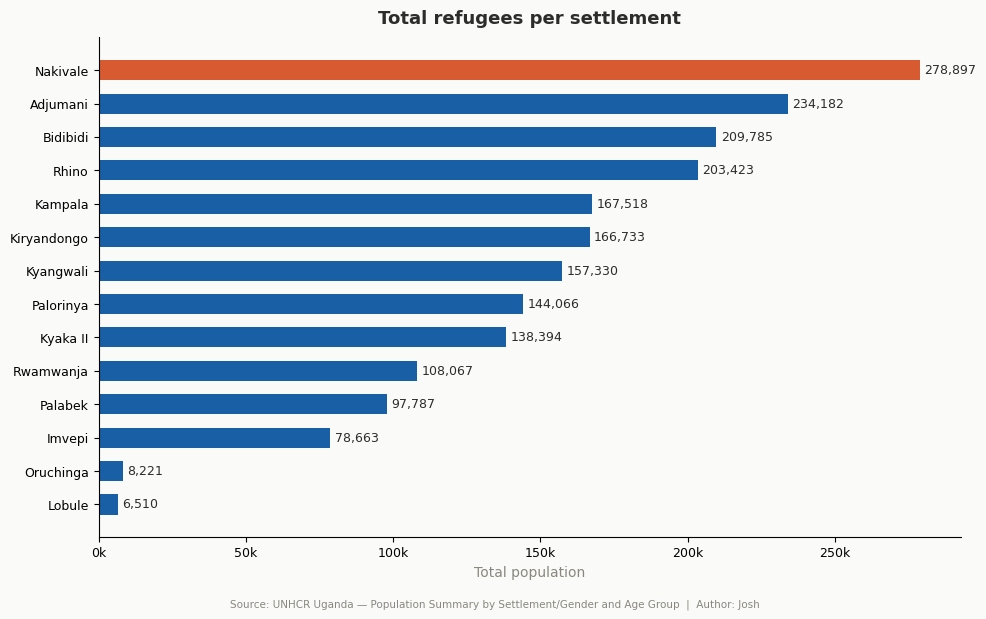

In [16]:
settled = df.sort_values("Grand Total", ascending=True)
colors  = [ACCENT if v == settled["Grand Total"].max() else BLUE
           for v in settled["Grand Total"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(settled["Settlement"], settled["Grand Total"],
               color=colors, height=0.6, edgecolor="none")

for bar, val in zip(bars, settled["Grand Total"]):
    ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=9, color=TEXT)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_xlabel("Total population", fontsize=10, color=MUTED)
ax.set_title("Total refugees per settlement", fontsize=13,
             fontweight="bold", pad=10, color=TEXT)
ax.tick_params(labelsize=9)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
fig.text(0.5, -0.02, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

## 3. Age & gender pyramid

A classic population pyramid showing the **overall** age and gender split across all settlements combined.
Female bars extend to the left (blue); male bars to the right (grey).

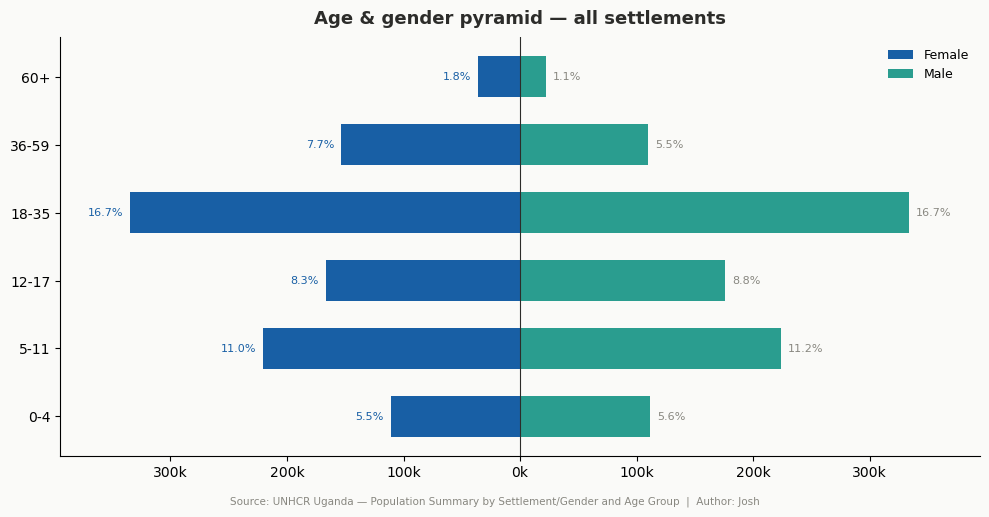

In [17]:
age_map = {
    "0-4":   ("0-4 Female",  "0-4 Male"),
    "5-11":  ("5-11 Female", "5-11 Male"),
    "12-17": ("12-17 Female","12-17 Male"),
    "18-35": ("18-35 Female","18-35 Male"),
    "36-59": ("36-59 Female","36-59 Male"),
    "60+":   ("60+ Female",  "60+ Male"),
}

fem_vals = [totals[age_map[a][0]] for a in AGE_GROUPS]
mal_vals = [totals[age_map[a][1]] for a in AGE_GROUPS]
grand    = sum(fem_vals) + sum(mal_vals)
y        = np.arange(len(AGE_GROUPS))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y, [-v for v in fem_vals], color=BLUE, height=0.6,
        edgecolor="none", label="Female")
ax.barh(y,  mal_vals,               color=TEAL, height=0.6,
        edgecolor="none", label="Male")

max_val = max(max(fem_vals), max(mal_vals))
ax.set_xlim(-max_val * 1.18, max_val * 1.18)

for i, (f, m) in enumerate(zip(fem_vals, mal_vals)):
    ax.text(-f - 6000, i, f"{f/grand*100:.1f}%",
            va="center", ha="right", fontsize=8, color=BLUE)
    ax.text( m + 6000, i, f"{m/grand*100:.1f}%",
            va="center", ha="left",  fontsize=8, color=MUTED)

ax.set_yticks(y)
ax.set_yticklabels(AGE_GROUPS, fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x)/1000:.0f}k"))
ax.axvline(0, color=TEXT, linewidth=0.8)
ax.set_title("Age & gender pyramid — all settlements", fontsize=13,
             fontweight="bold", pad=10, color=TEXT)
ax.legend(fontsize=9, frameon=False)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
fig.text(0.5, -0.02, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

## 4. Age composition by settlement

A stacked bar chart showing how each of the settlements breaks down by age group.
Darker blue = older age group.

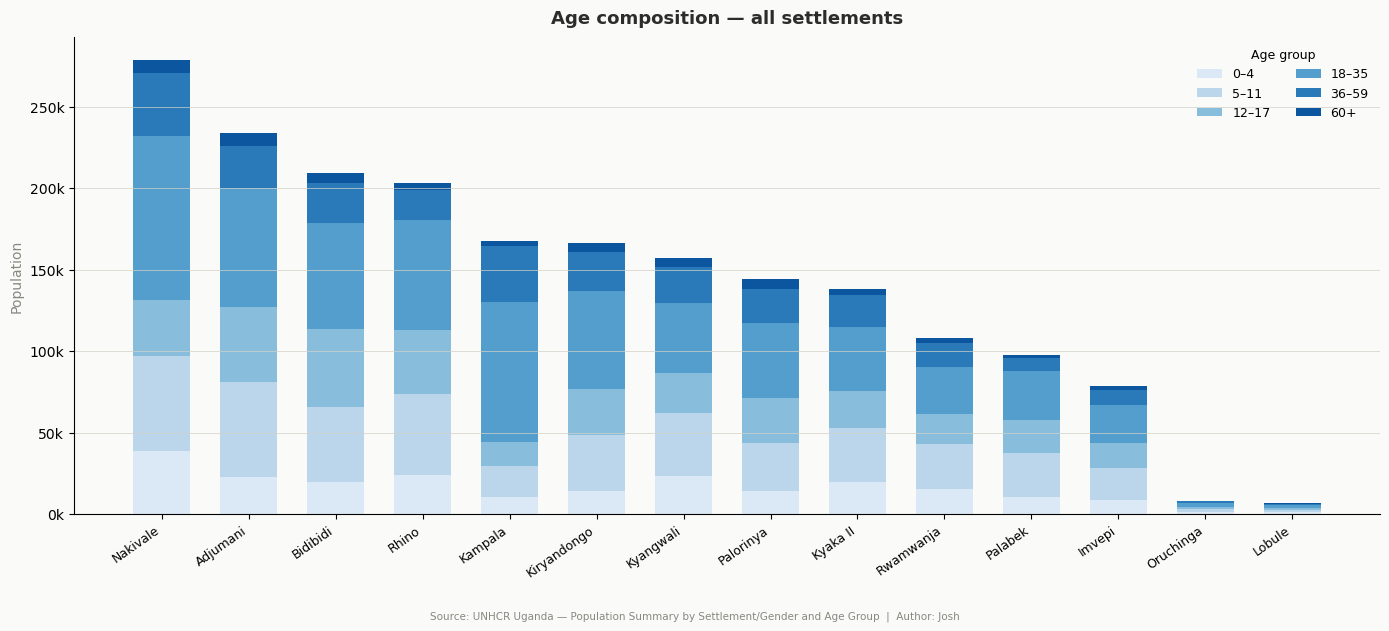

In [18]:
x      = np.arange(len(df))
bottom = np.zeros(len(df))

fig, ax = plt.subplots(figsize=(14, 6))

for col, lbl, clr in zip(AGE_COLS, AGE_LABELS, AGE_COLORS):
    ax.bar(x, df[col], bottom=bottom, label=lbl,
           color=clr, edgecolor="none", width=0.65)
    bottom += df[col].values

ax.set_xticks(x)
ax.set_xticklabels(df["Settlement"], rotation=35, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.set_ylabel("Population", fontsize=10, color=MUTED)
ax.set_title("Age composition — all settlements", fontsize=13,
             fontweight="bold", pad=10, color=TEXT)
ax.legend(title="Age group", fontsize=9, title_fontsize=9,
          frameon=False, loc="upper right", ncol=2)
ax.grid(axis="x", visible=False)
fig.text(0.5, -0.04, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

## 5. Female vs male comparison

Grouped bars showing the total female and male population for the **top 10** settlements side by side.

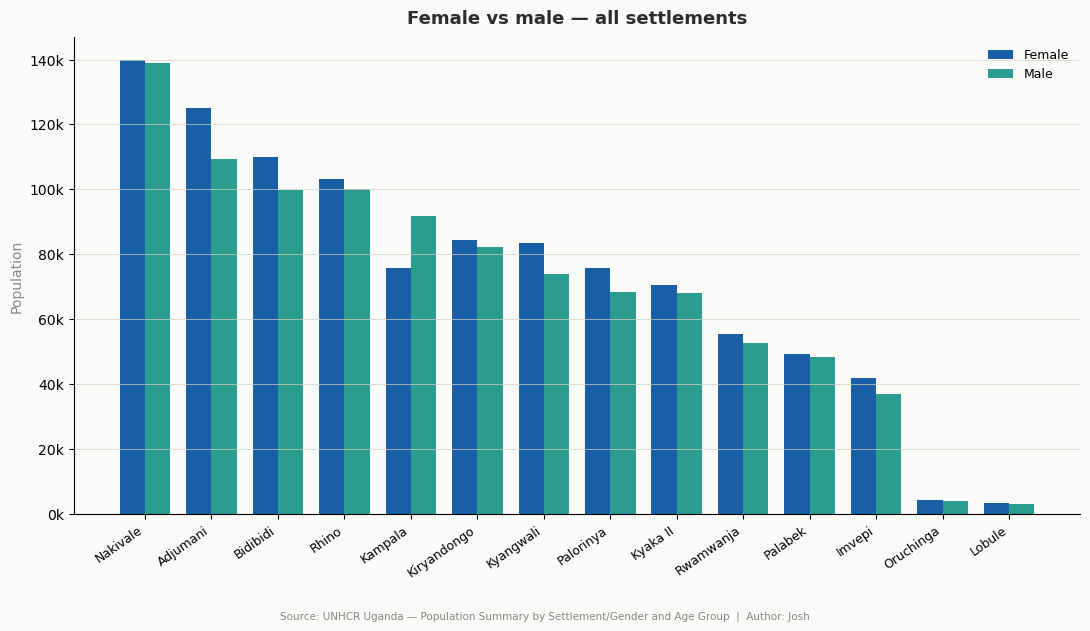

In [19]:
x2 = np.arange(len(df))
w  = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x2 - w/2, df["Total Female"], width=w, color=BLUE,
       edgecolor="none", label="Female")
ax.bar(x2 + w/2, df["Total Male"],   width=w, color=TEAL,
       edgecolor="none", label="Male")

ax.set_xticks(x2)
ax.set_xticklabels(df["Settlement"], rotation=35, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.set_ylabel("Population", fontsize=10, color=MUTED)
ax.set_title("Female vs male — all settlements", fontsize=13,
             fontweight="bold", pad=10, color=TEXT)
ax.legend(fontsize=9, frameon=False)
ax.grid(axis="x", visible=False)
fig.text(0.5, -0.04, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

## 6. Overall age-group share

A donut chart showing the **percentage share** of each age group across the entire population.
The total population is displayed in the centre.

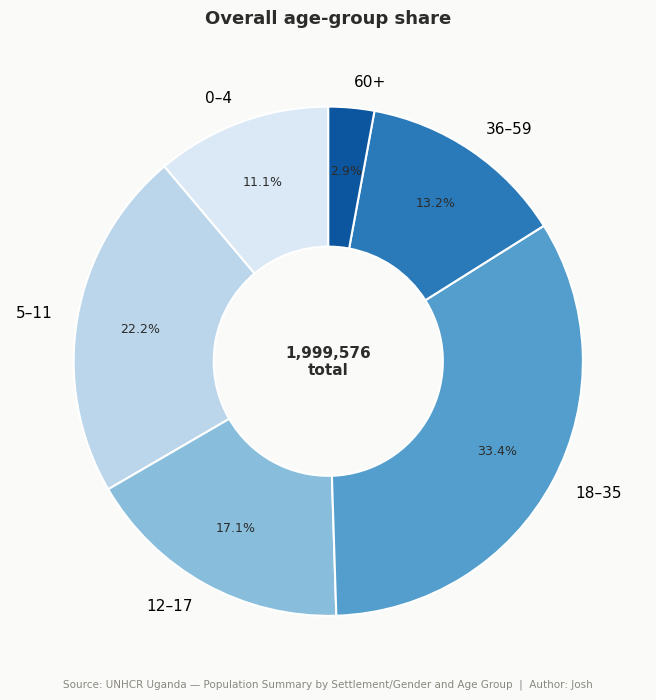

In [20]:
age_totals = [totals[c] for c in AGE_COLS]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    age_totals,
    labels=AGE_LABELS,
    autopct="%1.1f%%",
    colors=AGE_COLORS,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5),
)
for t  in texts:     t.set_fontsize(11)
for at in autotexts: at.set_fontsize(9); at.set_color(TEXT)

ax.text(0, 0, f"{int(sum(age_totals)):,}\ntotal",
        ha="center", va="center", fontsize=11,
        fontweight="bold", color=TEXT)
ax.set_title("Overall age-group share", fontsize=13,
             fontweight="bold", pad=14, color=TEXT)
fig.text(0.5, 0.01, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

## 7. Full dashboard

All five charts combined into a single exportable figure.
Saved to `refugee_population_dashboard.png`.

Saved → refugee_population_dashboard.png


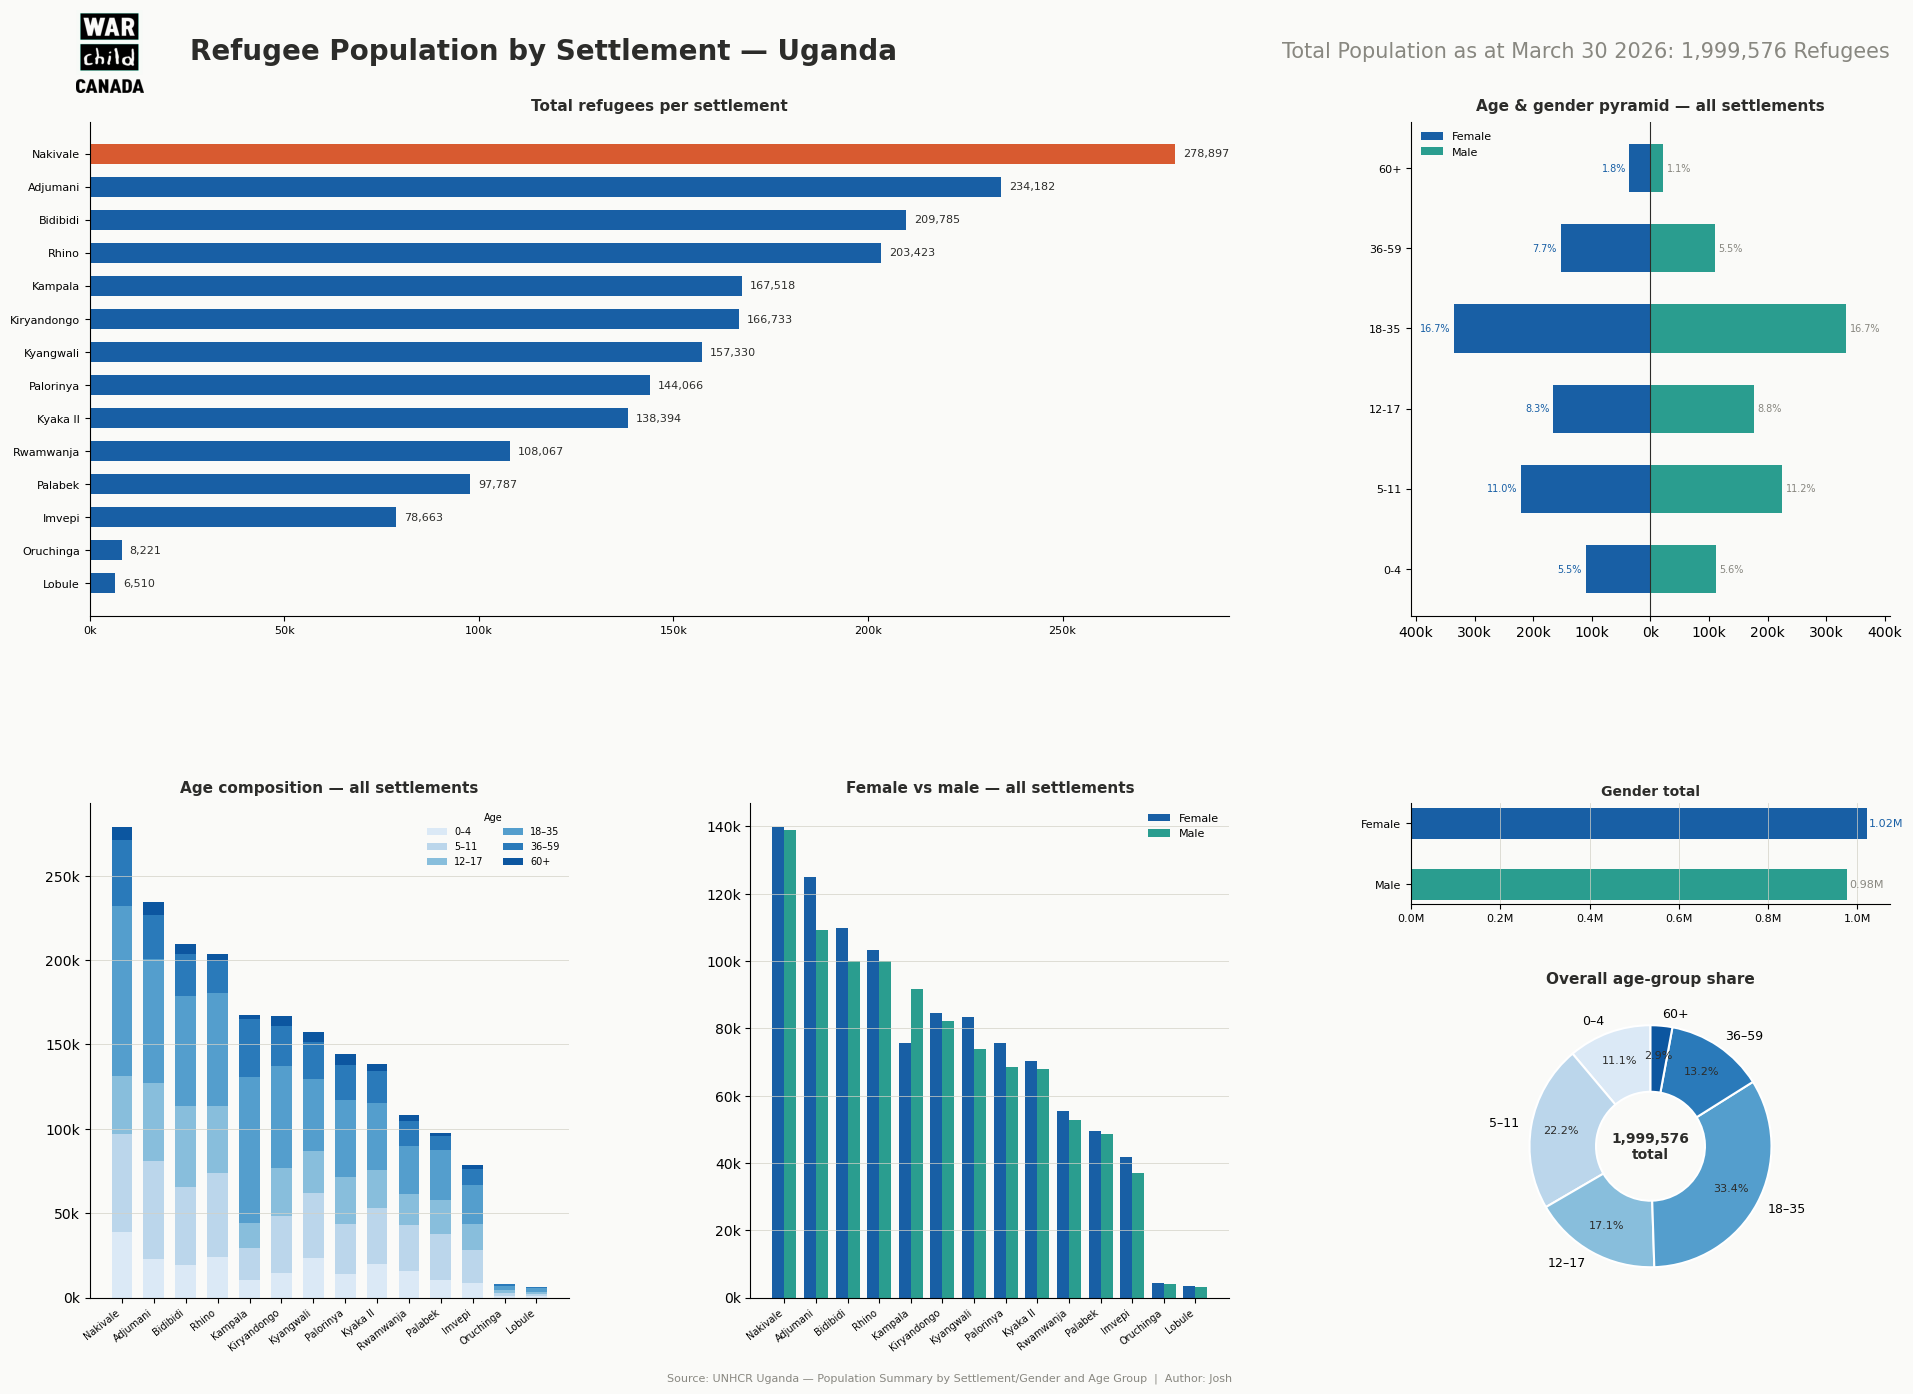

In [21]:
fig = plt.figure(figsize=(20, 14), facecolor="#FAFAF8")

total_refugees = df["Grand Total"].sum()

# Add Logo to the top-left
from PIL import Image
logo_ax = fig.add_axes([0.05, 0.93, 0.06, 0.06]) # [left, bottom, width, height]
logo_img = np.array(Image.open('Logos/wcc.png'))
logo_ax.imshow(logo_img)
logo_ax.axis('off')

# Title and total population on the same line
# Positioned to the right of the logo (Title) and far right (Subtitle)
fig.text(0.12, 0.96, "Refugee Population by Settlement — Uganda",
         ha="left", va="center", fontsize=20, fontweight="bold", color=TEXT)
fig.text(0.97, 0.96, f"Total Population as at March 30 2026: {total_refugees:,.0f} Refugees",
         ha="right", va="center", fontsize=15, color=MUTED)

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.38, wspace=0.38,
                       top=0.91, bottom=0.07,
                       left=0.07, right=0.97)

ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# bottom-right cell split into 2 rows: gender bar (top) + pie (bottom)
gs_inner = gridspec.GridSpecFromSubplotSpec(
    2, 1, subplot_spec=gs[1, 2], hspace=0.45, height_ratios=[1, 3]
)
ax6 = fig.add_subplot(gs_inner[0])   # gender bar
ax5 = fig.add_subplot(gs_inner[1])   # pie chart

# ── Chart 1 — total per settlement ────────────────────────────────────────
settled = df.sort_values("Grand Total", ascending=True)
colors  = [ACCENT if v == settled["Grand Total"].max() else BLUE
           for v in settled["Grand Total"]]
bars = ax1.barh(settled["Settlement"], settled["Grand Total"],
                color=colors, height=0.6, edgecolor="none")
for bar, val in zip(bars, settled["Grand Total"]):
    ax1.text(bar.get_width() + 2000, bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", fontsize=8, color=TEXT)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax1.set_title("Total refugees per settlement", fontsize=11,
              fontweight="bold", pad=8, color=TEXT)
ax1.tick_params(labelsize=8)
ax1.grid(axis="x"); ax1.grid(axis="y", visible=False)
ax1.set_title("Total refugees per settlement", fontsize=11,
              fontweight="bold", pad=8, color=TEXT)
ax1.set_facecolor("#FAFAF8")

# ── Chart 2 — age & gender pyramid ────────────────────────────────────────
y = np.arange(len(AGE_GROUPS))
# Calculate fem_vals and mal_vals overall totals
fem_vals = df[fem_cols].sum().values
mal_vals = df[mal_cols].sum().values
grand = df["Grand Total"].sum()

ax2.barh(y, [-v for v in fem_vals], color=BLUE, height=0.6,
         edgecolor="none", label="Female")
ax2.barh(y,  mal_vals,               color=TEAL, height=0.6,
         edgecolor="none", label="Male")

max_val = max(max(fem_vals), max(mal_vals))
ax2.set_xlim(-max_val * 1.22, max_val * 1.22)

for i, (f, m) in enumerate(zip(fem_vals, mal_vals)):
    ax2.text(-f - 6000, i, f"{f/grand*100:.1f}%",
             va="center", ha="right", fontsize=7, color=BLUE)
    ax2.text( m + 6000, i, f"{m/grand*100:.1f}%",
             va="center", ha="left",  fontsize=7, color=MUTED)
ax2.set_yticks(y); ax2.set_yticklabels(AGE_GROUPS, fontsize=8)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x)/1000:.0f}k"))
ax2.axvline(0, color=TEXT, linewidth=0.8)
ax2.set_title("Age & gender pyramid — all settlements", fontsize=11,
              fontweight="bold", pad=8, color=TEXT)
ax2.legend(fontsize=8, frameon=False, loc="upper left")
ax2.grid(axis="x"); ax2.grid(axis="y", visible=False)
ax2.set_facecolor("#FAFAF8")

# ── Chart 6 — gender summary horizontal bar ───────────────────────────────
total_f = sum(fem_vals)
total_m = sum(mal_vals)
ax6.barh([1, 0], [total_f, total_m],
         color=[BLUE, TEAL], height=0.5, edgecolor="none")
ax6.set_yticks([0, 1])
ax6.set_yticklabels(["Male", "Female"], fontsize=8)
ax6.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax6.text(total_f + 5000, 1, f"{total_f/1e6:.2f}M",
         va="center", fontsize=8, color=BLUE)
ax6.text(total_m + 5000, 0, f"{total_m/1e6:.2f}M",
         va="center", fontsize=8, color=MUTED)
ax6.set_title("Gender total", fontsize=10, fontweight="bold", pad=6, color=TEXT)
ax6.tick_params(labelsize=8)
ax6.spines[["top", "right"]].set_visible(False)
ax6.grid(axis="x", color="#D3D1C7", linewidth=0.5)
ax6.grid(axis="y", visible=False)
ax6.set_facecolor("#FAFAF8")

# ── Chart 5 — overall age-group share ─────────────────────────────────────
age_totals = [totals[c] for c in AGE_COLS]
wedges, texts, autotexts = ax5.pie(
    age_totals, labels=AGE_LABELS, autopct="%1.1f%%",
    colors=AGE_COLORS, startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5),
)
for t  in texts:     t.set_fontsize(9)
for at in autotexts: at.set_fontsize(8); at.set_color(TEXT)
ax5.text(0, 0, f"{int(sum(age_totals)):,}\ntotal",
         ha="center", va="center", fontsize=10,
         fontweight="bold", color=TEXT)
ax5.set_title("Overall age-group share", fontsize=11,
              fontweight="bold", pad=8, color=TEXT)

# ── Chart 3 — age composition, all settlements ────────────────────────────
xb     = np.arange(len(df))
bottom = np.zeros(len(df))
for col, lbl, clr in zip(AGE_COLS, AGE_LABELS, AGE_COLORS):
    ax3.bar(xb, df[col], bottom=bottom, label=lbl,
            color=clr, edgecolor="none", width=0.65)
    bottom += df[col].values
ax3.set_xticks(xb)
ax3.set_xticklabels(df["Settlement"], rotation=38, ha="right", fontsize=7)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax3.set_title("Age composition — all settlements", fontsize=11,
              fontweight="bold", pad=8, color=TEXT)
ax3.legend(title="Age", fontsize=7, title_fontsize=7,
           frameon=False, loc="upper right", ncol=2)
ax3.grid(axis="x", visible=False)
ax3.set_facecolor("#FAFAF8")

# ── Chart 4 — female vs male, all settlements ─────────────────────────────
x2 = np.arange(len(df)); w = 0.38
ax4.bar(x2 - w/2, df["Total Female"], width=w, color=BLUE,
        edgecolor="none", label="Female")
ax4.bar(x2 + w/2, df["Total Male"],   width=w, color=TEAL,
        edgecolor="none", label="Male")
ax4.set_xticks(x2)
ax4.set_xticklabels(df["Settlement"], rotation=38, ha="right", fontsize=7)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax4.set_title("Female vs male — all settlements", fontsize=11,
              fontweight="bold", pad=8, color=TEXT)
ax4.legend(fontsize=8, frameon=False)
ax4.grid(axis="x", visible=False)
ax4.set_facecolor("#FAFAF8")

# ── Footer ─────────────────────────────────────────────────────────────────
fig.text(0.5, 0.01, FOOTER, ha="center", fontsize=8, color=MUTED)


plt.savefig("refugee_population_dashboard.png",
            dpi=150, bbox_inches="tight", facecolor="#FAFAF8")
print("Saved → refugee_population_dashboard.png")
plt.show()

**Child vs adult split** — under-18 vs 18+ per settlement

in comparing child Vs Adult split per settlement, we are using the grouped bar chart. This places Child and Adult side by side so that we easily compare. Other options could be stacked bar charts. Contributors in this project can try to create this too.

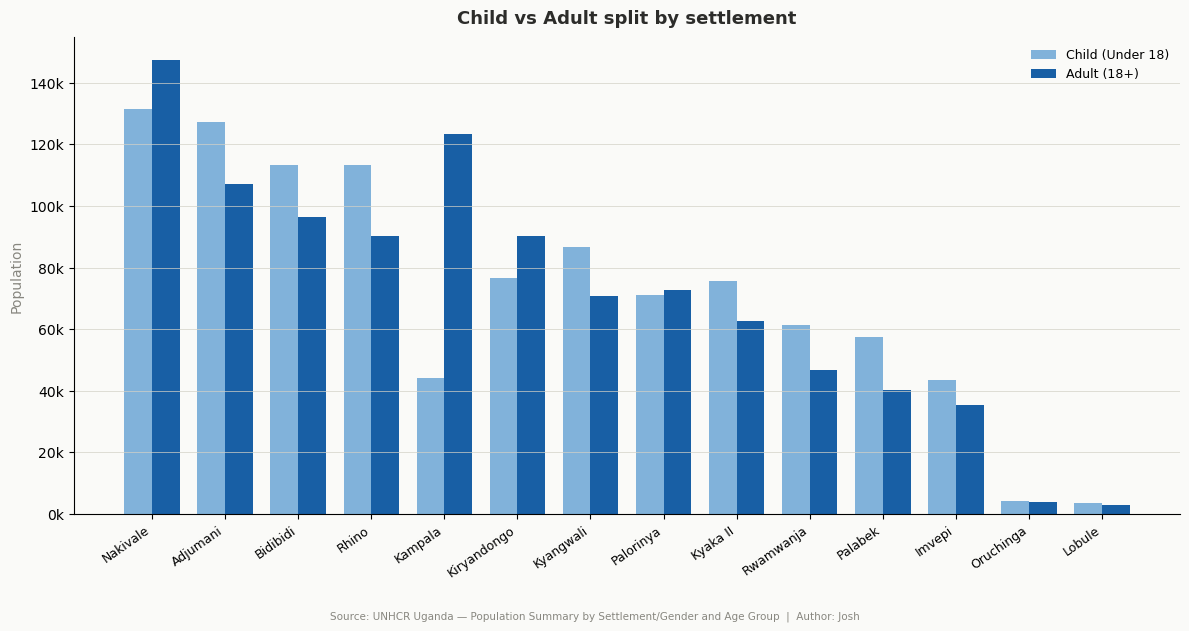

In [22]:
# Calculate Total Child and Total Adult populations
df["Total Child"] = df[["0-4 Total", "5-11 Total", "12-17 Total"]].sum(axis=1)
df["Total Adult"] = df[["18-35 Total", "36-59 Total", "60+ Total"]].sum(axis=1)

x = np.arange(len(df))
w = 0.38  # Adjust width for grouped bars

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Child bars shifted to the left
ax.bar(x - w/2, df["Total Child"], width=w, color="#81B2DA", 
       edgecolor="none", label="Child (Under 18)")

# Plot Adult bars shifted to the right
ax.bar(x + w/2, df["Total Adult"], width=w, color=BLUE, 
       edgecolor="none", label="Adult (18+)")

ax.set_xticks(x)
ax.set_xticklabels(df["Settlement"], rotation=35, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.set_ylabel("Population", fontsize=10, color=MUTED)
ax.set_title("Child vs Adult split by settlement", fontsize=13,
             fontweight="bold", pad=10, color=TEXT)
ax.legend(fontsize=9, frameon=False)
ax.grid(axis="x", visible=False)
fig.text(0.5, -0.04, FOOTER, ha="center", fontsize=7.5, color=MUTED)

plt.tight_layout()
plt.show()

## 8. Settlement vs Age Pyramids

A side-by-side comparison of the demographic structures for the **Nakivale** and **Bidibidi** settlements.

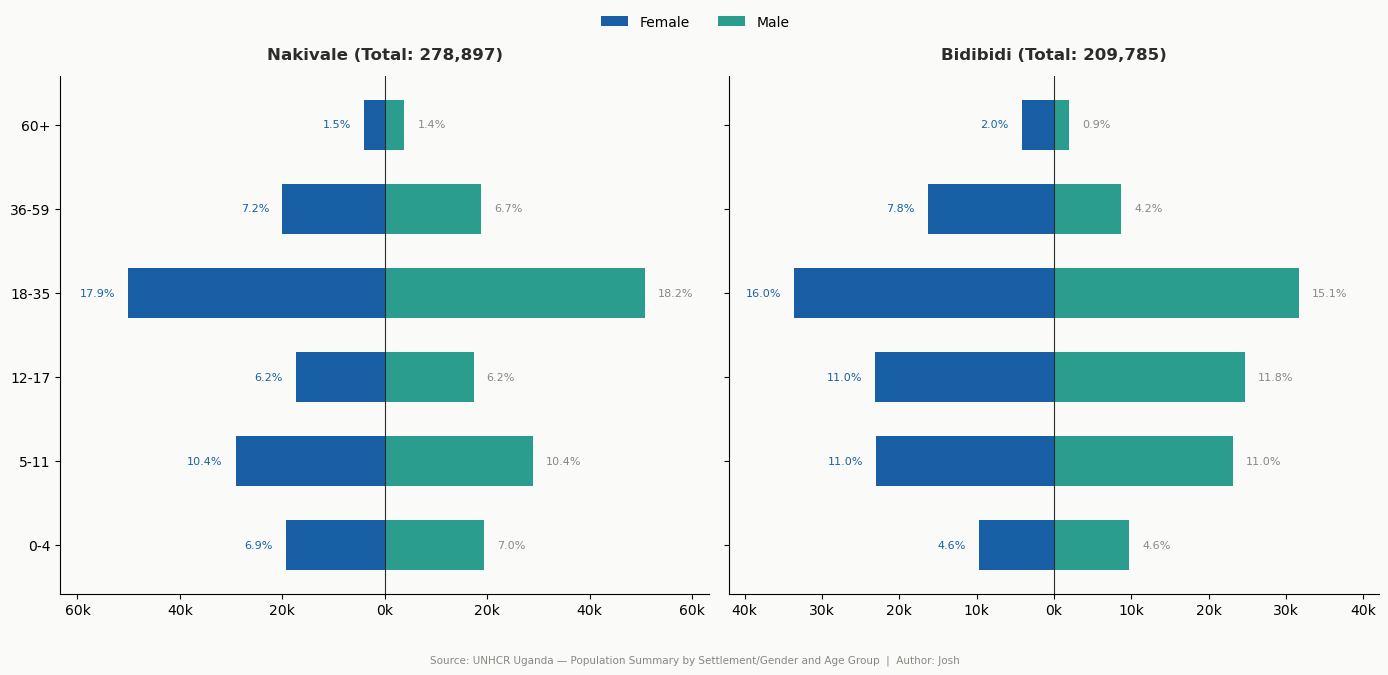

In [23]:
settlements_to_plot = ["Nakivale", "Bidibidi"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
y = np.arange(len(AGE_GROUPS))

for ax, settlement_name in zip(axes, settlements_to_plot):
    s_data = df[df["Settlement"] == settlement_name].iloc[0]
    
    fem_vals_s = [s_data[col] for col in fem_cols]
    mal_vals_s = [s_data[col] for col in mal_cols]
    total_pop_s = s_data["Grand Total"]
    
    ax.barh(y, [-v for v in fem_vals_s], color=BLUE, height=0.6, 
            edgecolor="none", label="Female" if ax == axes[0] else "")
    ax.barh(y, mal_vals_s, color=TEAL, height=0.6, 
            edgecolor="none", label="Male" if ax == axes[0] else "")
    
    max_val_s = max(max(fem_vals_s), max(mal_vals_s))
    ax.set_xlim(-max_val_s * 1.25, max_val_s * 1.25)
    
    for i, (f, m) in enumerate(zip(fem_vals_s, mal_vals_s)):
        ax.text(-f - (max_val_s * 0.05), i, f"{f/total_pop_s*100:.1f}%",
                va="center", ha="right", fontsize=8, color=BLUE)
        ax.text( m + (max_val_s * 0.05), i, f"{m/total_pop_s*100:.1f}%",
                va="center", ha="left",  fontsize=8, color=MUTED)
                
    ax.set_yticks(y)
    ax.set_yticklabels(AGE_GROUPS, fontsize=10)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x)/1000:.0f}k"))
    ax.axvline(0, color=TEXT, linewidth=0.8)
    
    ax.set_title(f"{settlement_name} (Total: {total_pop_s:,.0f})", 
                 fontsize=12, fontweight="bold", pad=12, color=TEXT)
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False, fontsize=10)
fig.text(0.5, -0.05, FOOTER, ha="center", fontsize=7.5, color=MUTED)

plt.tight_layout()
plt.show()

# Part 2 — Country of Origin & Humanitarian Analysis

This section analyses refugee data through the lens of **education and livelihoods programming**.
It uses `refugee_country_of_origin.csv` alongside the age/gender data already loaded above.

**Cells in this section**
- **A** — Country of origin frequency (where refugees come from)
- **B** — Stacked 100% composition bar (nationality mix per settlement)
- **C** — Heatmap: settlement × country of origin
- **D** — Diversity index per settlement
- **E** — NGO summary panel: school-age children & working-age adults
- **F** — Key conclusions for education & livelihoods NGOs

> Make sure `refugee_country_of_origin.csv` is in the same folder.

In [24]:
# ── Load country of origin CSV ─────────────────────────────────────────
orig = pd.read_csv("refugee_country_of_origin.csv")

ORIGIN_COLS = ["South_Sudan","DRC","Sudan","Eritrea",
               "Somalia","Burundi","Rwanda","Ethiopia","Other"]

ORIGIN_LABELS = {
    "South_Sudan": "South Sudan",
    "DRC":         "DR Congo",
    "Sudan":       "Sudan",
    "Eritrea":     "Eritrea",
    "Somalia":     "Somalia",
    "Burundi":     "Burundi",
    "Rwanda":      "Rwanda",
    "Ethiopia":    "Ethiopia",
    "Other":       "Other",
}

ORIGIN_COLORS = {
    "South_Sudan": "#4FA3E0",
    "DRC":         "#F5C342",
    "Sudan":       "#E07B39",
    "Eritrea":     "#6DBF67",
    "Somalia":     "#C94040",
    "Burundi":     "#9B59B6",
    "Rwanda":      "#1ABC9C",
    "Ethiopia":    "#E91E63",
    "Other":       "#AAAAAA",
}

print(f"✅ Origin data loaded — {len(orig)} settlements, {orig['Total'].sum():,.0f} total refugees")
orig[["Settlement","Total"]].sort_values("Total", ascending=False)

✅ Origin data loaded — 14 settlements, 1,999,576 total refugees


,Settlement,Total
0,Nakivale,278897
1,Adjumani,234182
2,Bidibidi,209785
3,Rhino,203423
4,Kampala,167518
5,Kiryandongo,166733
6,Kyangwali,157330
7,Palorinya,144066
8,Kyaka II,138394
9,Rwamwanja,108067


## Cell A — Country of origin frequency

Total refugees in Uganda by country of origin, ranked largest to smallest.
Each bar is labelled with the absolute count and percentage share.

Two countries South Sudan and DR Congo account for over 85% of all refugees.
This has direct implications for language-of-instruction choices in education programmes.

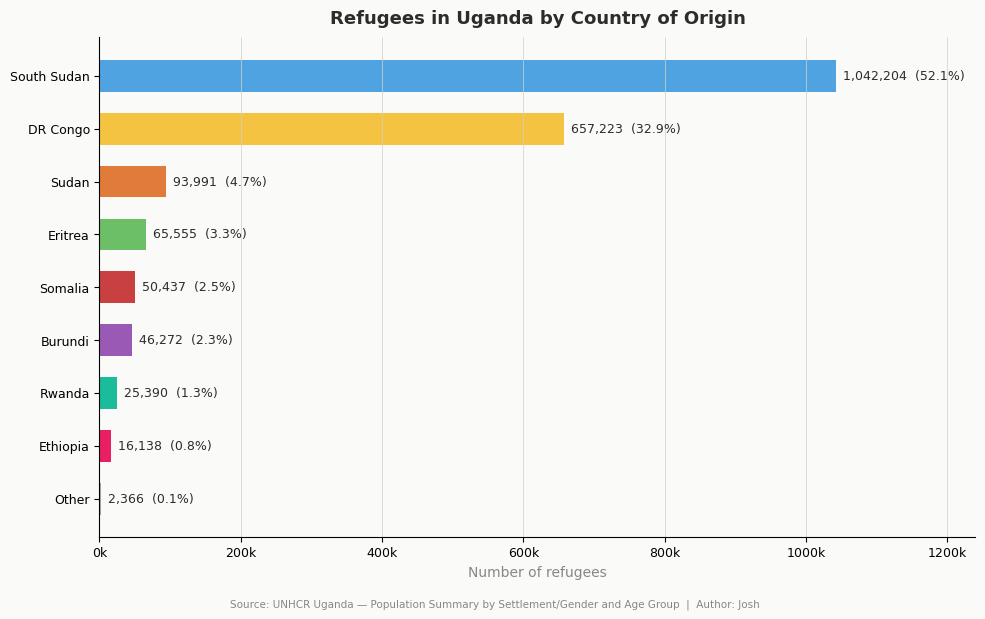

In [25]:
# Sum each origin column across all settlements
totals_by_origin = orig[ORIGIN_COLS].sum().sort_values(ascending=True)
grand_total      = totals_by_origin.sum()
labels           = [ORIGIN_LABELS[c] for c in totals_by_origin.index]
colors           = [ORIGIN_COLORS[c] for c in totals_by_origin.index]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(labels, totals_by_origin.values,
               color=colors, height=0.6, edgecolor="none")

# Labels: count + percentage
for bar, val in zip(bars, totals_by_origin.values):
    pct = val / grand_total * 100
    ax.text(
        bar.get_width() + grand_total * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}  ({pct:.1f}%)",
        va="center", fontsize=9, color=TEXT
    )

ax.set_xlim(0, grand_total * 0.62)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.set_xlabel("Number of refugees", fontsize=10, color=MUTED)
ax.set_title("Refugees in Uganda by Country of Origin",
             fontsize=13, fontweight="bold", pad=10, color=TEXT)
ax.tick_params(labelsize=9)
ax.grid(axis="x", color="#D3D1C7", linewidth=0.5)
ax.grid(axis="y", visible=False)
fig.text(0.5, -0.02, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

## Nationality composition per settlement

Every settlement shown as a full bar divided by country of origin share.
Settlements sorted by South Sudan share — northern settlements appear at the top,
DRC-dominated western settlements at the bottom.

Kampala and Kiryandongo stand out as the most mixed.
Purely blue bars (South Sudan) are ideal targets for South Sudanese curriculum.
Purely yellow bars (DRC) need Francophone/Congolese education approaches.

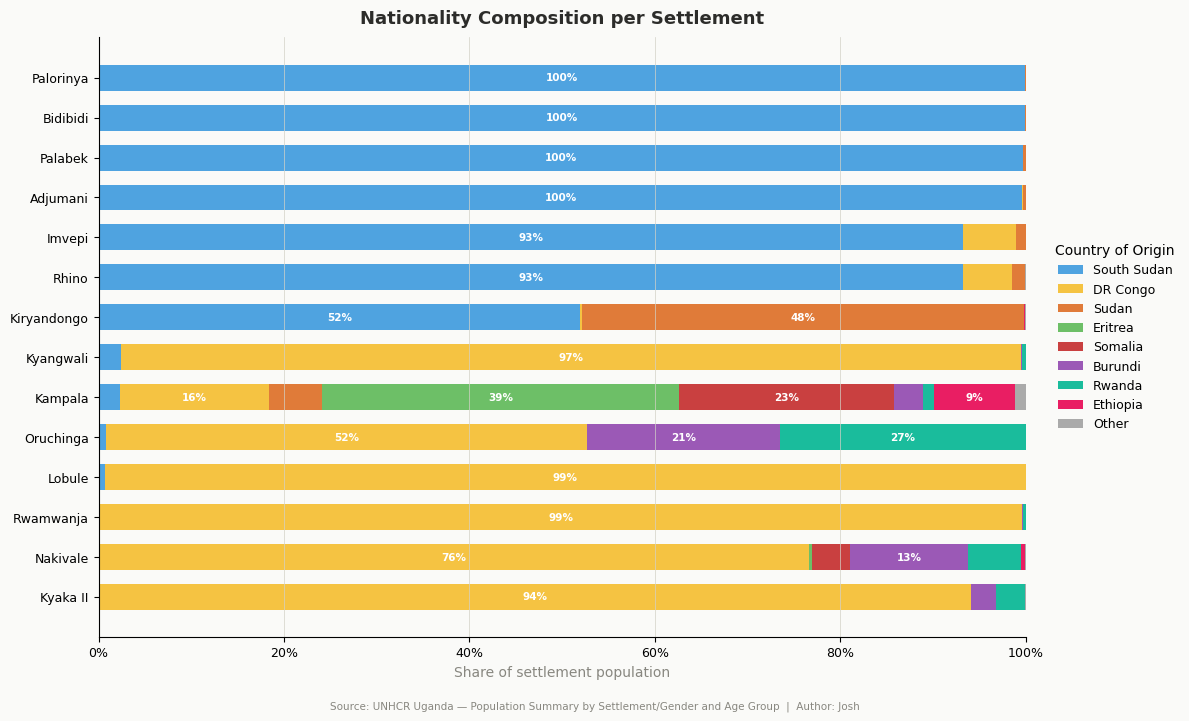

In [27]:
# Sort settlements by South Sudan share descending
orig_pct = orig.copy()
for col in ORIGIN_COLS:
    orig_pct[col] = orig_pct[col] / orig_pct["Total"] * 100
orig_pct = orig_pct.sort_values("South_Sudan", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

left = np.zeros(len(orig_pct))
for col in ORIGIN_COLS:
    vals = orig_pct[col].values
    bars = ax.barh(orig_pct["Settlement"], vals,
                   left=left, color=ORIGIN_COLORS[col],
                   height=0.65, edgecolor="none",
                   label=ORIGIN_LABELS[col])
    # Label slices wider than 8%
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 8:
            ax.text(l + v/2, i, f"{v:.0f}%",
                    ha="center", va="center",
                    fontsize=7.5, color="white", fontweight="bold")
    left += vals

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Share of settlement population", fontsize=10, color=MUTED)
ax.set_title("Nationality Composition per Settlement",
             fontsize=13, fontweight="bold", pad=10, color=TEXT)
ax.tick_params(labelsize=9)
ax.grid(axis="x", color="#D3D1C7", linewidth=0.5)
ax.grid(axis="y", visible=False)

# Place legend outside the chart on the right side
ax.legend(title="Country of Origin", fontsize=9, title_fontsize=10, 
          frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.text(0.5, -0.02, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

## Heatmap: settlement × country of origin

Each cell shows the **percentage share** of that country in that settlement.
Darker = higher concentration. White = negligible presence.

**What to look for:**
- The diagonal-like pattern confirms two distinct geographic clusters
- Kampala's row lights up across many columns — unique diversity signature
- Kiryandongo is the only settlement with two strong columns (South Sudan + Sudan)

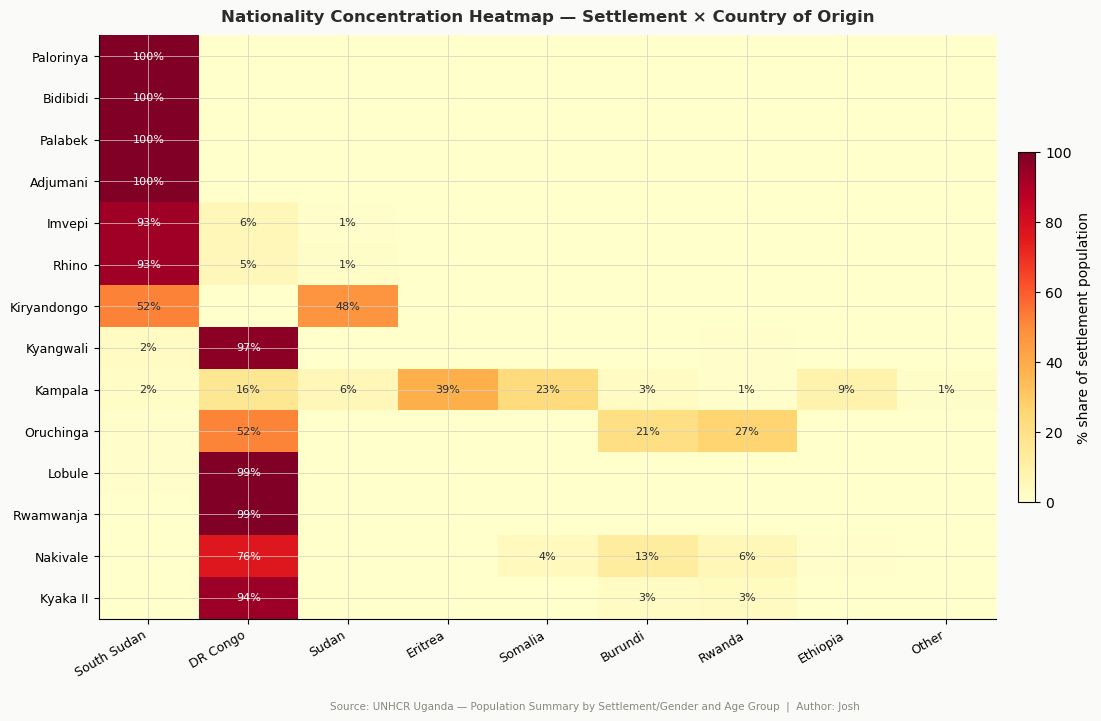

In [28]:
import matplotlib.colors as mcolors

# Build % matrix — settlements as rows, countries as columns
heat = orig.set_index("Settlement")[ORIGIN_COLS].copy()
heat = heat.div(heat.sum(axis=1), axis=0) * 100
heat = heat.sort_values("South_Sudan", ascending=False)  # north→south order

col_labels = [ORIGIN_LABELS[c] for c in ORIGIN_COLS]

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd",
               vmin=0, vmax=100)

# Axis ticks
ax.set_xticks(range(len(ORIGIN_COLS)))
ax.set_xticklabels(col_labels, fontsize=9, rotation=30, ha="right")
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index, fontsize=9)

# Annotate each cell with its value if > 1%
for i in range(len(heat)):
    for j in range(len(ORIGIN_COLS)):
        val = heat.values[i, j]
        if val > 1:
            txt_color = "white" if val > 55 else "#2C2C2A"
            ax.text(j, i, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=8, color=txt_color)

plt.colorbar(im, ax=ax, label="% share of settlement population",
             shrink=0.6, pad=0.02)
ax.set_title("Nationality Concentration Heatmap — Settlement × Country of Origin",
             fontsize=12, fontweight="bold", pad=10, color=TEXT)
fig.text(0.5, -0.02, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

## Diversity index per settlement

**Simpson's Diversity Index (1 − D)** measures how mixed a settlement is.

- Score = **1.0** → perfectly diverse (equal share of all nationalities)
- Score = **0.0** → completely homogeneous (one nationality only)

Formula: `1 − Σ(pᵢ²)` where pᵢ is the proportion of each nationality.

A high diversity score means programming needs to be multilingual and culturally adaptive — higher coordination cost.A low score means simpler, more targeted programming is viable.

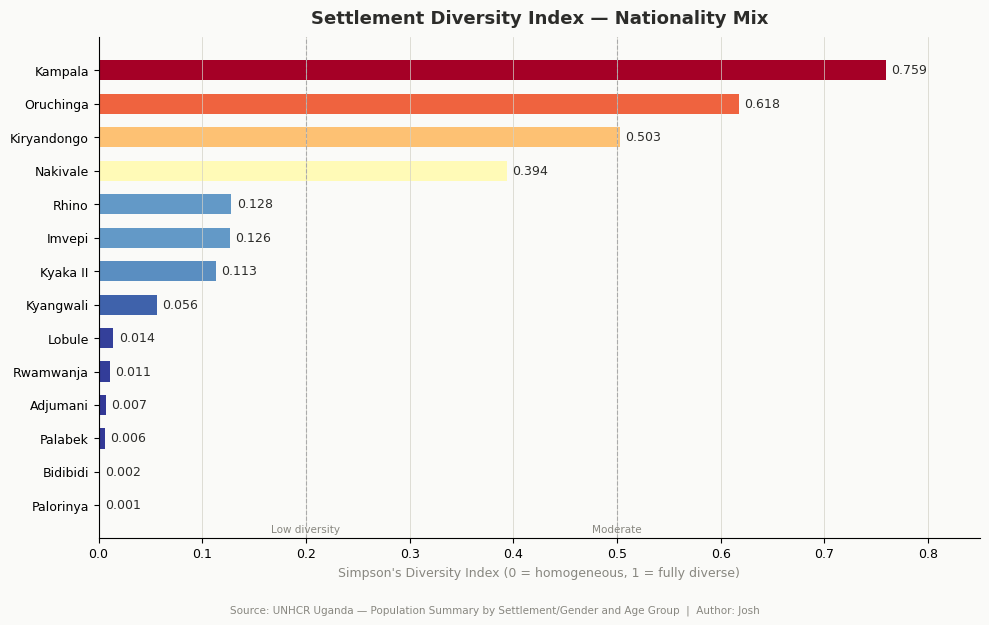

In [29]:
# Compute Simpson's Diversity Index for each settlement
def simpsons(row):
    total = row[ORIGIN_COLS].sum()
    proportions = row[ORIGIN_COLS] / total
    return 1 - (proportions ** 2).sum()

orig["diversity"] = orig.apply(simpsons, axis=1)
div_sorted = orig.sort_values("diversity", ascending=True)

# Colour by score: low = blue (homogeneous), high = orange (diverse)
norm   = plt.Normalize(div_sorted["diversity"].min(),
                       div_sorted["diversity"].max())
cmap   = plt.cm.RdYlBu_r
colors = [cmap(norm(v)) for v in div_sorted["diversity"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(div_sorted["Settlement"], div_sorted["diversity"],
               color=colors, height=0.6, edgecolor="none")

for bar, val in zip(bars, div_sorted["diversity"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9, color=TEXT)

# Reference lines
ax.axvline(0.2, color="#AAAAAA", linewidth=0.8, linestyle="--")
ax.axvline(0.5, color="#AAAAAA", linewidth=0.8, linestyle="--")
ax.text(0.2, -0.8, "Low diversity",  fontsize=7.5, color=MUTED, ha="center")
ax.text(0.5, -0.8, "Moderate",       fontsize=7.5, color=MUTED, ha="center")

ax.set_xlim(0, 0.85)
ax.set_xlabel("Simpson's Diversity Index (0 = homogeneous, 1 = fully diverse)",
              fontsize=9, color=MUTED)
ax.set_title("Settlement Diversity Index — Nationality Mix",
             fontsize=13, fontweight="bold", pad=10, color=TEXT)
ax.tick_params(labelsize=9)
ax.grid(axis="x", color="#D3D1C7", linewidth=0.5)
ax.grid(axis="y", visible=False)
fig.text(0.5, -0.03, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

## Targeting Panel

Two side-by-side charts built from the age/gender CSV:

- **Left:** School-age children (5–17 years) per settlement — ranked
  → Priority list for **education** programmes
- **Right:** Working-age adults (18–59 years) per settlement — ranked
  → Priority list for **livelihoods** programmes

Both charts show absolute numbers and the settlement's share of the national total.

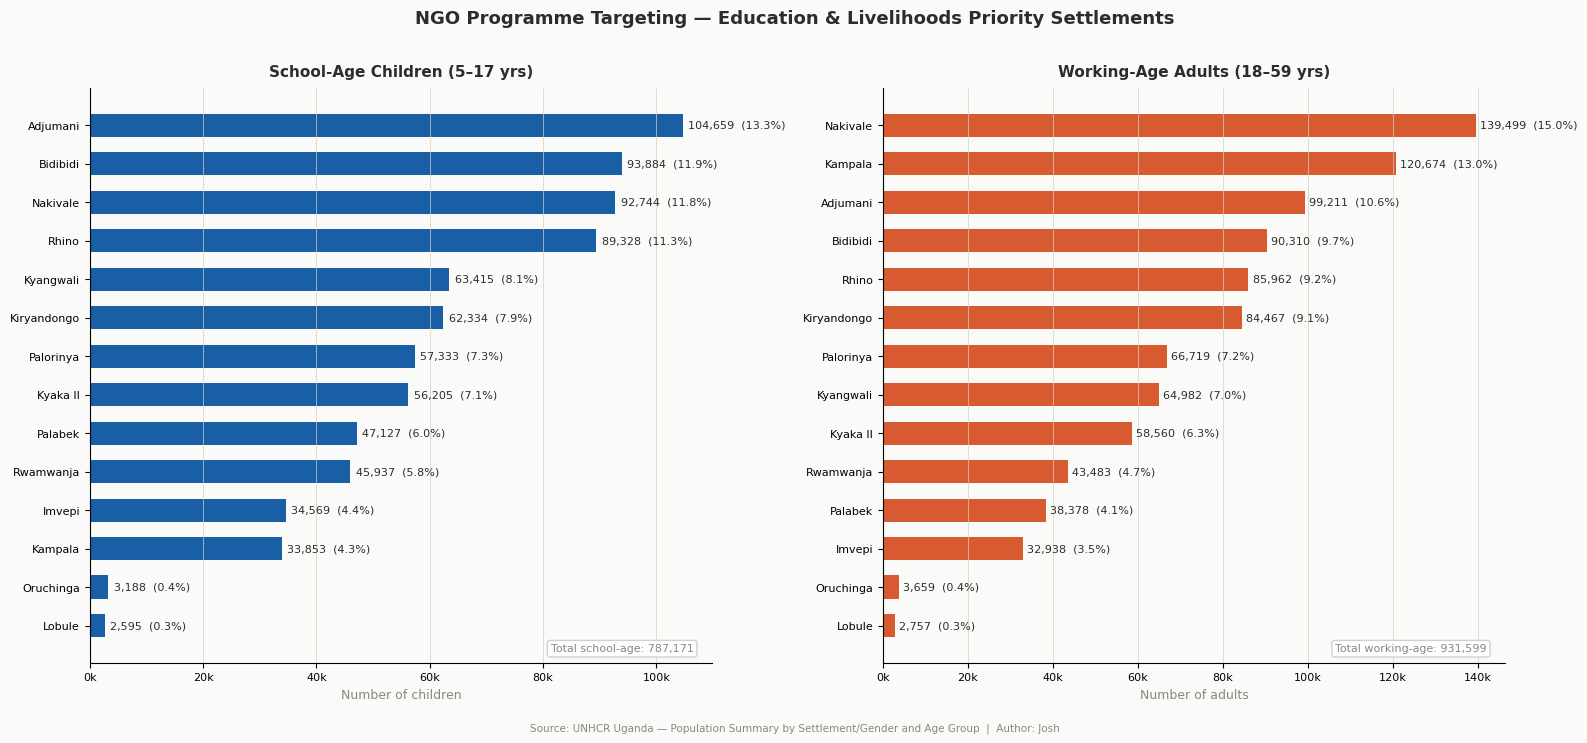

In [31]:
# ── Pull from the age/gender dataframe already loaded above ───────────────
ngo = df.copy()   # df was loaded in Section 1 from refugee_population_by_settlement.csv

# School-age: 5-11 + 12-17
ngo["School_Age"]   = ngo["5-11 Total"] + ngo["12-17 Total"]
# Working-age: 18-35 + 36-59
ngo["Working_Age"]  = ngo["18-35 Total"] + ngo["36-59 Total"]
# Under 5 (most vulnerable, high nutrition/ECD need)
ngo["Under_5"]      = ngo["0-4 Total"]

edu_sorted  = ngo.sort_values("School_Age",  ascending=True)
live_sorted = ngo.sort_values("Working_Age", ascending=True)

edu_total  = ngo["School_Age"].sum()
live_total = ngo["Working_Age"].sum()

fig, (ax_edu, ax_live) = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: Education (school-age 5-17) ────────────────────────────────────
bars_edu = ax_edu.barh(
    edu_sorted["Settlement"], edu_sorted["School_Age"],
    color=BLUE, height=0.6, edgecolor="none"
)
for bar, val in zip(bars_edu, edu_sorted["School_Age"]):
    pct = val / edu_total * 100
    ax_edu.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}  ({pct:.1f}%)",
        va="center", fontsize=8, color=TEXT
    )
ax_edu.set_title("School-Age Children (5–17 yrs)",
                 fontsize=11, fontweight="bold", pad=8, color=TEXT)
ax_edu.set_xlabel("Number of children", fontsize=9, color=MUTED)
ax_edu.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
ax_edu.tick_params(labelsize=8)
ax_edu.grid(axis="x", color="#D3D1C7", linewidth=0.5)
ax_edu.grid(axis="y", visible=False)
ax_edu.set_facecolor("#FAFAF8")
total_label = f"Total school-age: {edu_total:,.0f}"
ax_edu.text(0.97, 0.02, total_label, transform=ax_edu.transAxes,
            ha="right", fontsize=8, color=MUTED,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#CCCCCC", alpha=0.9))

# ── Right: Livelihoods (working-age 18-59) ───────────────────────────────
bars_live = ax_live.barh(
    live_sorted["Settlement"], live_sorted["Working_Age"],
    color=ACCENT, height=0.6, edgecolor="none"
)
for bar, val in zip(bars_live, live_sorted["Working_Age"]):
    pct = val / live_total * 100
    ax_live.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}  ({pct:.1f}%)",
        va="center", fontsize=8, color=TEXT
    )
ax_live.set_title("Working-Age Adults (18–59 yrs)",
                  fontsize=11, fontweight="bold", pad=8, color=TEXT)
ax_live.set_xlabel("Number of adults", fontsize=9, color=MUTED)
ax_live.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
ax_live.tick_params(labelsize=8)
ax_live.grid(axis="x", color="#D3D1C7", linewidth=0.5)
ax_live.grid(axis="y", visible=False)
ax_live.set_facecolor("#FAFAF8")
total_label2 = f"Total working-age: {live_total:,.0f}"
ax_live.text(0.97, 0.02, total_label2, transform=ax_live.transAxes,
             ha="right", fontsize=8, color=MUTED,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                       edgecolor="#CCCCCC", alpha=0.9))

fig.suptitle("NGO Programme Targeting — Education & Livelihoods Priority Settlements",
             fontsize=13, fontweight="bold", color=TEXT, y=1.01)
fig.text(0.5, -0.02, FOOTER, ha="center", fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

In [33]:
# ── Compute all summary statistics ────────────────────────────────────────
grand_total       = orig["Total"].sum()
ss_total          = orig["South_Sudan"].sum()
drc_total         = orig["DRC"].sum()
top3_edu          = ngo.nlargest(3, "School_Age")[["Settlement","School_Age"]]
top3_live         = ngo.nlargest(3, "Working_Age")[["Settlement","Working_Age"]]
most_diverse      = orig.loc[orig["diversity"].idxmax(), "Settlement"]
least_diverse     = orig.loc[orig["diversity"].idxmin(), "Settlement"]
total_school      = ngo["School_Age"].sum()
total_working     = ngo["Working_Age"].sum()
total_under5      = ngo["Under_5"].sum()
pct_school        = total_school / grand_total * 100
pct_working       = total_working / grand_total * 100
kampala_diversity = orig.loc[orig["Settlement"]=="Kampala", "diversity"].values[0]

print("=" * 65)
print(" KEY CONCLUSIONS — UGANDA REFUGEE DATA   (31 March 2026)")
print("=" * 65)

print(f"""
POPULATION OVERVIEW
   Total registered refugees & asylum seekers : {grand_total:>10,.0f}
   From South Sudan                           : {ss_total:>10,.0f}  ({ss_total/grand_total*100:.1f}%)
   From DR Congo                              : {drc_total:>10,.0f}  ({drc_total/grand_total*100:.1f}%)
   Combined SS + DRC share                    : {(ss_total+drc_total)/grand_total*100:.1f}%

EDUCATION PROGRAMMING
   Total school-age children (5–17 yrs)       : {total_school:>10,.0f}  ({pct_school:.1f}% of all refugees)
   Total under-5 (ECD priority)               : {total_under5:>10,.0f}
   Top 3 settlements for education investment :
      1. {top3_edu.iloc[0]['Settlement']:<15}  {top3_edu.iloc[0]['School_Age']:>8,.0f} school-age children
      2. {top3_edu.iloc[1]['Settlement']:<15}  {top3_edu.iloc[1]['School_Age']:>8,.0f} school-age children
      3. {top3_edu.iloc[2]['Settlement']:<15}  {top3_edu.iloc[2]['School_Age']:>8,.0f} school-age children

LIVELIHOODS PROGRAMMING
   Total working-age adults (18–59 yrs)       : {total_working:>10,.0f}  ({pct_working:.1f}% of all refugees)
   Top 3 settlements for livelihoods investment:
      1. {top3_live.iloc[0]['Settlement']:<15}  {top3_live.iloc[0]['Working_Age']:>8,.0f} working-age adults
      2. {top3_live.iloc[1]['Settlement']:<15}  {top3_live.iloc[1]['Working_Age']:>8,.0f} working-age adults
      3. {top3_live.iloc[2]['Settlement']:<15}  {top3_live.iloc[2]['Working_Age']:>8,.0f} working-age adults

DIVERSITY & PROGRAMME DESIGN
   Most diverse settlement  : {most_diverse} (index={kampala_diversity:.3f})
      → Needs multilingual, multi-cultural programme design
      → Higher coordination cost; consider consortium approach
   Most homogeneous         : {least_diverse}
      → Simpler targeted programming viable
      → Single language of instruction sufficient

TWO DISTINCT GEOGRAPHIC CORRIDORS
   NORTH (South Sudan majority) :
      Adjumani, Bidibidi, Palorinya, Palabek, Rhino, Imvepi, Lobule
      → English/Arabic instruction; South Sudanese curriculum alignment
   WEST (DRC majority) :
      Kyangwali, Rwamwanja, Kyaka II, Nakivale, Oruchinga
      → French/Swahili instruction; Congolese curriculum alignment
   SPECIAL CASE — Kiryandongo :
      ~52% South Sudan, ~48% Sudan — the only genuinely split settlement
      → Dual-track programming needed
""")
print("=" * 65)

 KEY CONCLUSIONS — UGANDA REFUGEE DATA   (31 March 2026)

POPULATION OVERVIEW
   Total registered refugees & asylum seekers :  1,999,576
   From South Sudan                           :  1,042,204  (52.1%)
   From DR Congo                              :    657,223  (32.9%)
   Combined SS + DRC share                    : 85.0%

EDUCATION PROGRAMMING
   Total school-age children (5–17 yrs)       :    787,171  (39.4% of all refugees)
   Total under-5 (ECD priority)               :    222,693
   Top 3 settlements for education investment :
      1. Adjumani          104,659 school-age children
      2. Bidibidi           93,884 school-age children
      3. Nakivale           92,744 school-age children

LIVELIHOODS PROGRAMMING
   Total working-age adults (18–59 yrs)       :    931,599  (46.6% of all refugees)
   Top 3 settlements for livelihoods investment:
      1. Nakivale          139,499 working-age adults
      2. Kampala           120,674 working-age adults
      3. Adjumani           